#### 1.- Código personal que calcule transformada de Fourier de una función f(x)

En particular, se muestra la transformada de la funcion cos(t)

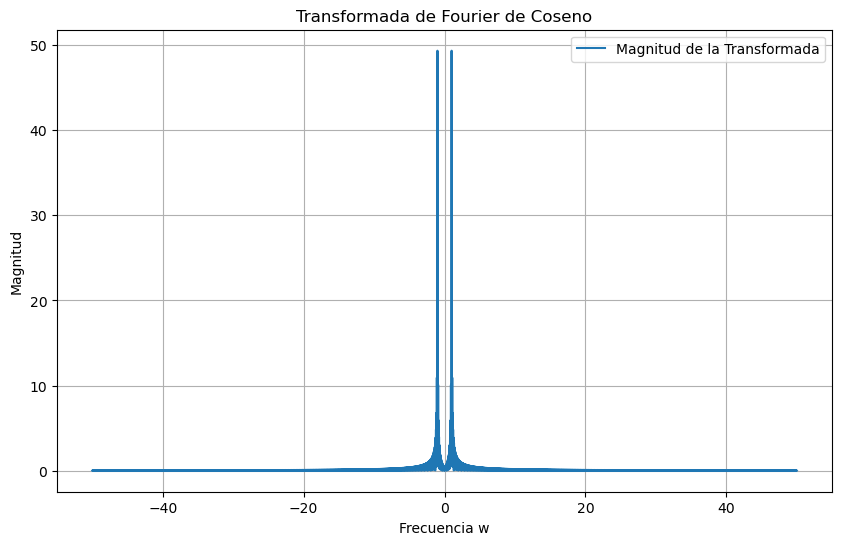

In [2]:
import sympy as owo
import numpy as uwu
import matplotlib as mlp
import matplotlib.pyplot as plt
from scipy import special
import math
import pandas as pd
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D


a_w=-50 #Limite inferior de frecuencias.
b_w=50 #Limite superior de frecuencias.

a=-50 #Limite inferior de tiempo de integracion.
b=50 #Limite superior de tiempo de integracion.
n=10000 #Numero de divisiones del tiempo de integracion (cuantos puntos se tomaran en el dominio temporal).
dt=(b-a)/n #Ancho de cada division el la recta temporal.


freq= uwu.linspace(a_w, b_w, num=(b_w - a_w) * 100)  #Genera las frecuencias que van a ser evaluadas en la transformada.

Y = uwu.zeros(freq.shape[0], dtype=complex) #Genera el vector de la misma dimension que las frecuencias generadas, guarda numeros complejos.

t = uwu.linspace(a, b, num=n) #Genera el tiempo donde va a ser evaluada la aproximacion de la integral en la transformada de Fourier.

for i, w in enumerate(freq): #Genera un ciclo donde para cada frecuencia en freq le corresponde un indice i
    Temp_X = uwu.cos(t)* uwu.exp(-1j * w * t) * dt #Representa el argumento de la integral en la def de la trans.Fourier
    Y[i] = uwu.sum(Temp_X)  # Sumar sobre todos los puntos de t, de modo que aproxima a la transformada y lo guarda en el vector Y

# Grafica la magnitud de la transformada
plt.figure(figsize=(10, 6))
plt.plot(freq, uwu.abs(Y), label='Magnitud de la Transformada')
plt.xlabel('Frecuencia w')
plt.ylabel('Magnitud')
plt.title('Transformada de Fourier de Coseno')
plt.legend()
plt.grid(True)
plt.show()
    


#### 2.- Muestra la transformada de Fourier de una Gaussiana con dispersión s y centrada en x0=0.

La parte real coincide con la maginutd de la transformada.

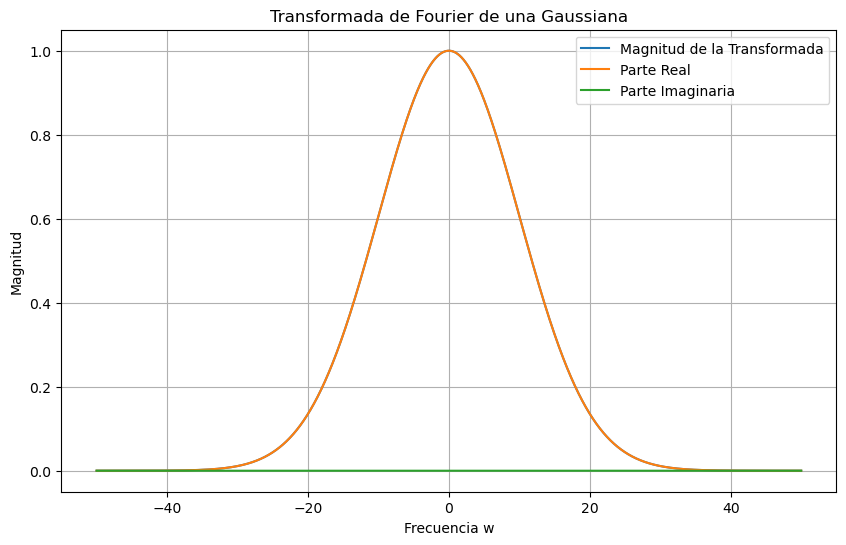

In [4]:

G = uwu.zeros(freq.shape[0], dtype=complex)
t_0=0 #Media de la Gaussiana
s=0.1

for i, w in enumerate(freq): #Genera un ciclo donde para cada frecuencia en freq le corresponde un indice i
    Temp_X =  (   ( 1/(uwu.sqrt(2*uwu.pi)*s) )*uwu.exp( -(t-t_0)**2/(2*s**2) ) )* uwu.exp(-1j * w * t) * dt #Representa el argumento de la integral en la def de la trans.Fourier
    G[i] = uwu.sum(Temp_X)  # Sumar sobre todos los puntos de t, de modo que aproxima a la transformada y lo guarda en el vector Y

G_r=uwu.real(G)
G_I=uwu.imag(G)

# Grafica la magnitud de la transformada
plt.figure(figsize=(10, 6))
plt.plot(freq, uwu.abs(G), label='Magnitud de la Transformada')
plt.plot(freq, G_r, label='Parte Real')
plt.plot(freq, G_I, label='Parte Imaginaria')
plt.xlabel('Frecuencia w')
plt.ylabel('Magnitud')
plt.title('Transformada de Fourier de una Gaussiana')
plt.legend()
plt.grid(True)
plt.show()


##### a) ¿Qué pasa si x0=1 con la transformada?

Podemos observar que a pesar de desplazar el maximo de la distribucion, en el espacio de Fourier permanece invariante. Sin embargo, la media distinta de cero, induce una fase compleja.

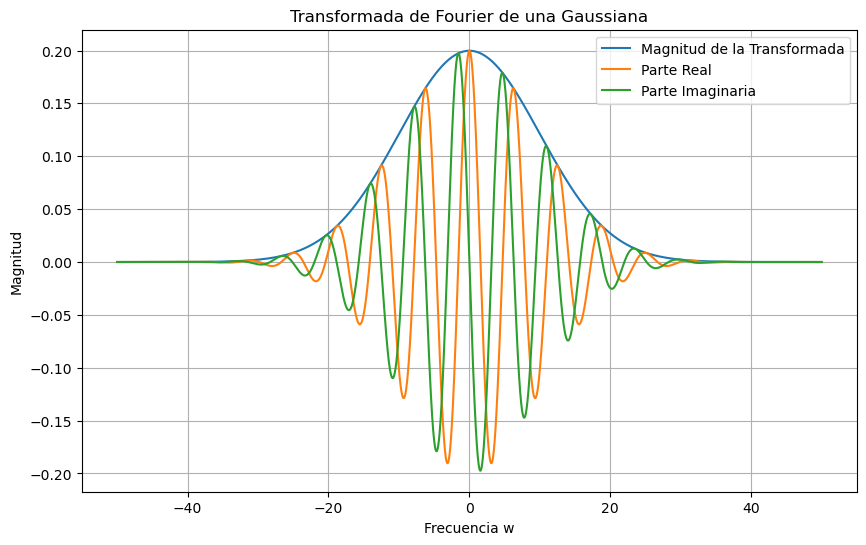

In [25]:
G = uwu.zeros(freq.shape[0], dtype=complex) 
t_0=1 #Media de la Gaussiana
s=0.1 #Dispersion de la Gaussiana

for i, w in enumerate(freq): 
    Temp_X =  (   ( 1/(uwu.sqrt(2*uwu.pi)*s) )*uwu.exp( -(t-t_0)**2/(2*s**2) ) )* uwu.exp(-1j * w * t) * dt #Transformada de la Gaussiana
    G[i] = uwu.sum(Temp_X) 

G_r=uwu.real(G)
G_I=uwu.imag(G)

# Grafica la magnitud de la transformada
plt.figure(figsize=(10, 6))
plt.plot(freq, uwu.abs(G), label='Magnitud de la Transformada')
plt.plot(freq, G_r, label='Parte Real')
plt.plot(freq, G_I, label='Parte Imaginaria')
plt.xlabel('Frecuencia w')
plt.ylabel('Magnitud')
plt.title('Transformada de Fourier de una Gaussiana')
plt.legend()
plt.grid(True)
plt.show()

##### b) Escoge varios valores de s, ¿Qué pasa si s=1?

Cuando s=1, en el espacio de Fourier tenemos una Gaussiana bastante estrecha, aproximandose a una delta de Dirac conforme vamos aumentando el valor de la dispersion.

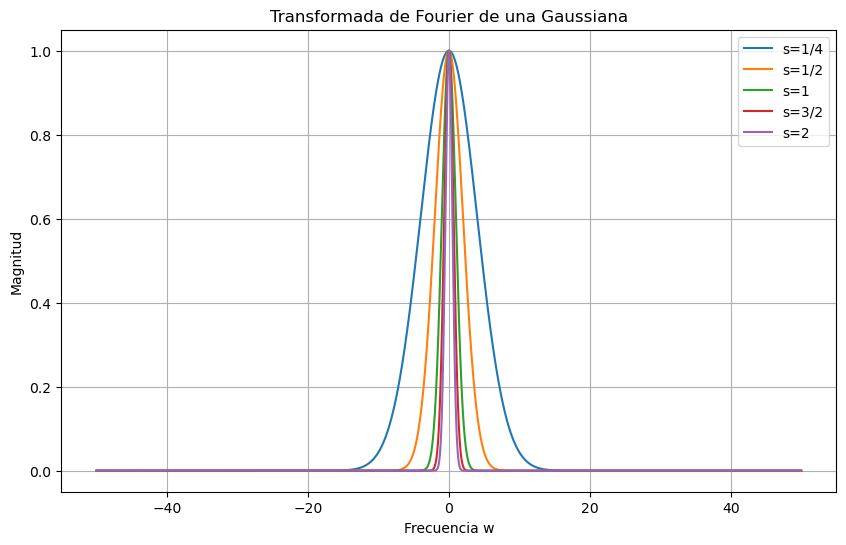

In [8]:
G1 = uwu.zeros(freq.shape[0], dtype=complex) 
G2 = uwu.zeros(freq.shape[0], dtype=complex) 
G3 = uwu.zeros(freq.shape[0], dtype=complex) 
G4 = uwu.zeros(freq.shape[0], dtype=complex) 
G5 = uwu.zeros(freq.shape[0], dtype=complex) 

t_0=0 

s1=0.25
s2=0.5
s3=1
s4=1.5
s5=2

for i, w in enumerate(freq): 
    Temp_X =  (   ( 1/(uwu.sqrt(2*uwu.pi)*s1) )*uwu.exp( -(t-t_0)**2/(2*s1**2) ) )* uwu.exp(-1j * w * t) * dt 
    G1[i] = uwu.sum(Temp_X) 

for i, w in enumerate(freq): 
    Temp_X =  (   ( 1/(uwu.sqrt(2*uwu.pi)*s2) )*uwu.exp( -(t-t_0)**2/(2*s2**2) ) )* uwu.exp(-1j * w * t) * dt 
    G2[i] = uwu.sum(Temp_X)  

for i, w in enumerate(freq): 
    Temp_X =  (   ( 1/(uwu.sqrt(2*uwu.pi)*s3) )*uwu.exp( -(t-t_0)**2/(2*s3**2) ) )* uwu.exp(-1j * w * t) * dt 
    G3[i] = uwu.sum(Temp_X)  

for i, w in enumerate(freq): 
    Temp_X =  (   ( 1/(uwu.sqrt(2*uwu.pi)*s4) )*uwu.exp( -(t-t_0)**2/(2*s4**2) ) )* uwu.exp(-1j * w * t) * dt 
    G4[i] = uwu.sum(Temp_X)  

for i, w in enumerate(freq): 
    Temp_X =  (   ( 1/(uwu.sqrt(2*uwu.pi)*s5) )*uwu.exp( -(t-t_0)**2/(2*s5**2) ) )* uwu.exp(-1j * w * t) * dt 
    G5[i] = uwu.sum(Temp_X)  

plt.figure(figsize=(10, 6))
plt.plot(freq, uwu.abs(G1), label='s=1/4')
plt.plot(freq, uwu.abs(G2), label='s=1/2')
plt.plot(freq, uwu.abs(G3), label='s=1')
plt.plot(freq, uwu.abs(G4), label='s=3/2')
plt.plot(freq, uwu.abs(G5), label='s=2')
plt.xlabel('Frecuencia w')
plt.ylabel('Magnitud')
plt.title('Transformada de Fourier de una Gaussiana')
plt.legend()
plt.grid(True)
plt.show()

##### c) Compara lo obtenido con la función FFT 

Comparando el codigo personal con la funcion FFT que posee numpy, podemos observar que las graficas son muy similares, aunque difieren bastante en la magnitud. Cabe destacar que como su nombre lo indica, la FFT tiene un tiempo de computo mucho menor comparado con el codigo que se programo en las celdas anteriores.

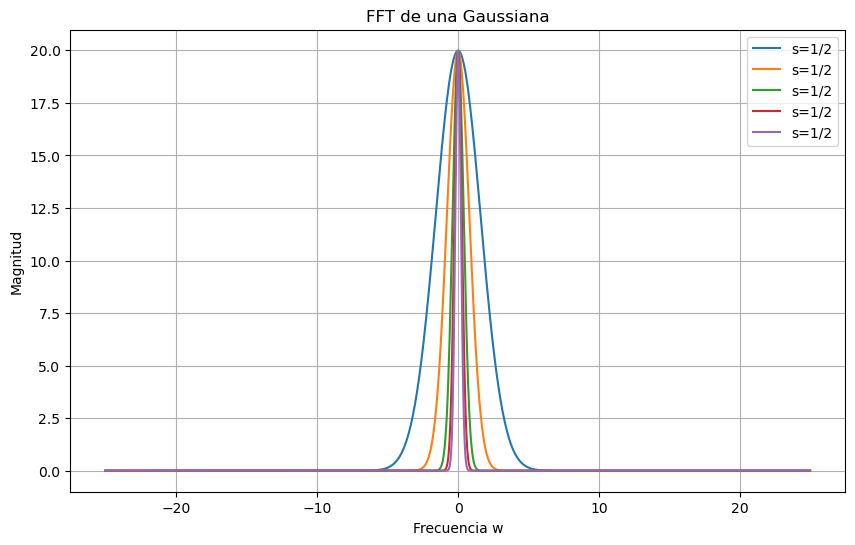

In [10]:

N_tiempo= 1000  # Número de puntos en el espacio temporal
N_w2=1000 #Numero de puntos en el espacio de frecuencias
N_w=50 #Numero que determina el rango donde se va a graficar en el espacio de frecuencias de -N_w/2 a N_w/2
dw = 1/N_w  # Intervalo de muestreo en el espacio de frecuencias


s1=0.25
s2=0.5
s3=1
s4=1.5
s5=2

t_0=0

t = uwu.linspace(-25, 25, N_tiempo) #Eje temporal
freqs = uwu.fft.fftfreq(N_w2, dw) #Genera el eje de las frecuencias
freqs_shifted = uwu.fft.fftshift(freqs) #Desplaza el eje de frecuencias para que sea alrededor del cero.

y1 = ( 1/(uwu.sqrt(2*uwu.pi)*s1) )*uwu.exp( -(t-t_0)**2/(2*s1**2) )
Y1= uwu.fft.fft(y1) #Calcula la transformada rapida
Y1_shift=uwu.fft.fftshift(Y1) #Shiftea los valores de Y para que coincidan con los del shift en la frecuencia shifteada

y2 = ( 1/(uwu.sqrt(2*uwu.pi)*s2) )*uwu.exp( -(t-t_0)**2/(2*s2**2) )
Y2= uwu.fft.fft(y2)
Y2_shift=uwu.fft.fftshift(Y2) 
y3 = ( 1/(uwu.sqrt(2*uwu.pi)*s3) )*uwu.exp( -(t-t_0)**2/(2*s3**2) )
Y3= uwu.fft.fft(y3)
Y3_shift=uwu.fft.fftshift(Y3) 

y4 = ( 1/(uwu.sqrt(2*uwu.pi)*s4) )*uwu.exp( -(t-t_0)**2/(2*s4**2) )
Y4= uwu.fft.fft(y4) 
Y4_shift=uwu.fft.fftshift(Y4) 

y5 = ( 1/(uwu.sqrt(2*uwu.pi)*s5) )*uwu.exp( -(t-t_0)**2/(2*s5**2) )
Y5= uwu.fft.fft(y5) 
Y5_shift=uwu.fft.fftshift(Y5) 

# Grafica la FFT
plt.figure(figsize=(10, 6))
plt.plot(freqs_shifted, uwu.abs(Y1_shift), label='s=1/2')
plt.plot(freqs_shifted, uwu.abs(Y2_shift), label='s=1/2')
plt.plot(freqs_shifted, uwu.abs(Y3_shift), label='s=1/2')
plt.plot(freqs_shifted, uwu.abs(Y4_shift), label='s=1/2')
plt.plot(freqs_shifted, uwu.abs(Y5_shift), label='s=1/2')
plt.xlabel("Frecuencia w")
plt.ylabel("Magnitud")
plt.title("FFT de una Gaussiana")
plt.legend()
plt.grid(True)
plt.show()


#### 3.- Construye una caja de lado 1000 en 2 y 3 dimensiones de una distribución aletatoria de puntos.

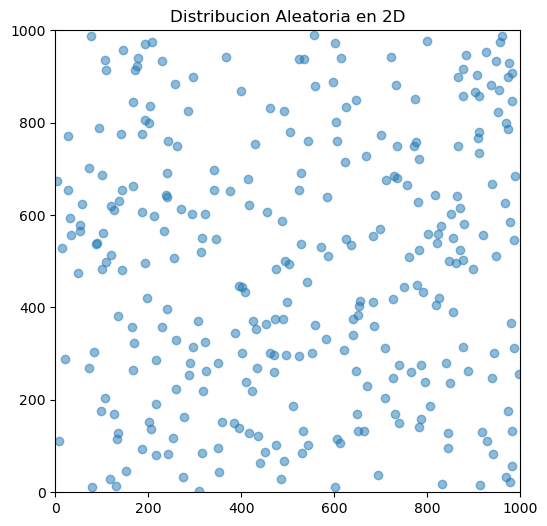

In [12]:
def spawn_puntos(n, d, t):
    if d == 2:
        x =  uwu.random.uniform(0, t, n) #Genera numeros aleatorios de 0 a t en x
        y = uwu.random.uniform(0, t ,n) #Genera numeros aleatorios de 0 a t en x
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
    elif d == 3:
        x = uwu.random.uniform(0, t, n)
        y = uwu.random.uniform(0, t, n)
        z = uwu.random.uniform(0, t, n)
        puntos = uwu.vstack((x, y, z)).T #Ordena los datos en una matriz de n x 3
    return puntos

def grafica_2d(p,tam): #Grafica los puntos aleatorios en 2d
    plt.figure(figsize=(6,6))
    plt.scatter(p[:,0], p[:,1], alpha=0.5) #Toma los valores en x e y en el spawn de puntos y los grafica
    plt.xlim(0, tam)
    plt.ylim(0, tam)
    plt.title("Distribucion Aleatoria en 2D")
    plt.show()

def grafica_3d(p,tam): #Grafica los puntos aleatorios en 3d
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(p[:,0], p[:,1], p[:,2], alpha=0.5) #Toma los valores en x, y, z en el spawn de puntos y los grafica
    ax.set_xlim([0, tam])
    ax.set_ylim([0, tam])
    ax.set_zlim([0, tam])
    ax.set_title("Distribucion Aleatoria en 3D")
    plt.show()

# Caracteristicas de la grafica

dim = 2  # Dimension
num_p = 300  # Cantidad de puntos
tam=1000   #Tamaño del grafico
p = spawn_puntos(num_p, dim, tam) #Genera los puntos, segun las caracteristicas anteriores

if dim == 2:
    grafica_2d(p,tam)
elif dim == 3:
    grafica_3d(p,tam)


#### 4.- Código que calcule histograma de distancias para 2d y 3d de una distribución de puntos aleatorios, escogiendo el tamaño de los bins, y normalizada a que su area sea 1.

[   0. 1362. 1516. 1937. 2265. 2612. 2831. 3049. 3054. 3063. 3047. 2962.
 2886. 2720. 2544. 2284. 1954. 1621. 1176.  812.  485.  301.  186.  109.
   53.   17.    4.    0.]
44850.0


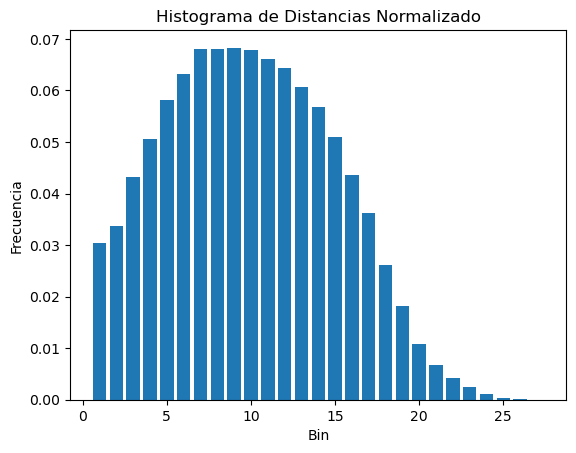

In [14]:
def Histo_distancias(d, dim_hist, num_p, p, bin_size): #Funcion que calcula el histograma
    Hist = uwu.zeros(dim_hist)
    
    if d == 2:
        for i in range(num_p):
            for j in range(i + 1, num_p):
                dist = uwu.sqrt((p[i, 0] - p[j, 0]) ** 2 + (p[i, 1] - p[j, 1]) ** 2)
                bin = int(dist / bin_size)  # Calcula a qué bin pertenece.
                
                if bin >= dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                    Hist[0] += 1  
                else:
                    Hist[max(1, bin)] += 1  # Si bin=0, se registra en Hist[1], de otro modo en Hist[bin]
                    
    elif d == 3:
        for i in range(num_p):
            for j in range(i + 1, num_p):
                dist = uwu.sqrt((p[i, 0] - p[j, 0]) ** 2 + (p[i, 1] - p[j, 1]) ** 2 + (p[i, 2] - p[j, 2]) ** 2)
                bin = int(dist / bin_size) 
                if bin >= dim_hist:  
                    Hist[0] += 1  
                else:
                    Hist[max(1, bin)] += 1 
                    
    return Hist


bin_size = 50  # Tamaño del Bin
dim_hist = 28  # Número de Bins: en realidad el numero es dim_hist-1, ya que, Hist[0] guarda todos los valores fuera de los rangos que estamos considerando.

Histo_Puntos = Histo_distancias(dim, dim_hist, num_p, p, bin_size) #Obtiene el histograma de distancias, segun las caracteristicas especificadas.
print(Histo_Puntos)

l=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l=l+Histo_Puntos[k]
    
print(l) #Imprime el numero total de frecuencias, coincide con N(N-1)/2.

Histo_Punto_N=Histo_Puntos/l #Divide el histograma entre el numero total de frecuencias para normalizarlo.

# Grafica el histograma 
plt.bar(range(1, dim_hist), Histo_Punto_N[1:], align='center')  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel("Frecuencia")
plt.title("Histograma de Distancias Normalizado")
plt.show()
    